# Task
 Advanced visualization and EDA techniques using Seaborn heatmaps and pair plots. Spotting correlations and outliers and tell a story with data.

## Load and inspect data

### Subtask:
Load a suitable dataset for demonstrating advanced visualizations and EDA techniques. Display the first few rows and basic information about the dataset.


**Reasoning**:
Import necessary libraries, load the dataset, and display the head and info to understand the data structure and types.



In [ ]:
import pandas as pd
import seaborn as sns

# Load the 'tips' dataset from seaborn
df = sns.load_dataset('tips')

# Display the first 5 rows
display(df.head())

# Display concise information about the DataFrame
display(df.info())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


None

## Create a heatmap

### Subtask:
Generate a heatmap to visualize the correlation matrix of the numerical features in the dataset.


**Reasoning**:
Calculate the correlation matrix and generate a heatmap to visualize the correlations between numerical features.



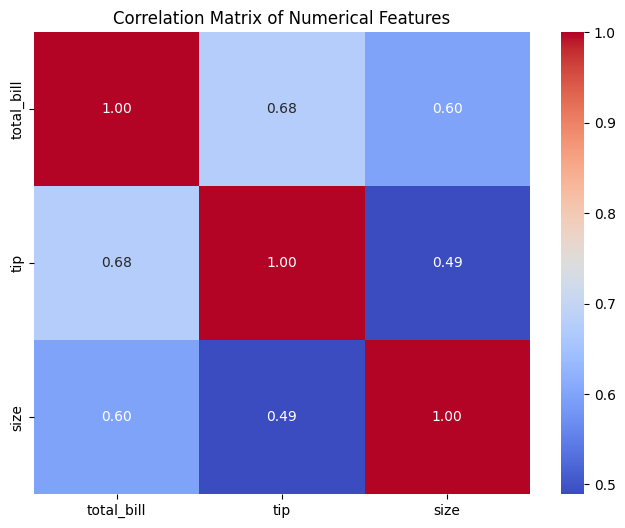

In [ ]:
import matplotlib.pyplot as plt

# Calculate the correlation matrix of numerical columns
corr_matrix = df.corr(numeric_only=True)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add a title to the heatmap
plt.title('Correlation Matrix of Numerical Features')

# Display the plot
plt.show()

## Create a pair plot

### Subtask:
Generate a pair plot to visualize the relationships between pairs of numerical features and the distribution of each feature.


**Reasoning**:
Generate a pair plot for the numerical columns in the DataFrame and add a title.



In [ ]:
# Generate a pair plot for numerical columns
pair_plot = sns.pairplot(df, numeric_only=True)

# Add a title to the pair plot
pair_plot.fig.suptitle('Pair Plot of Numerical Features', y=1.02)

# Display the plot
plt.show()

TypeError: pairplot() got an unexpected keyword argument 'numeric_only'

**Reasoning**:
The previous attempt failed because the `pairplot` function does not have a `numeric_only` parameter. I need to select only the numerical columns before creating the pair plot.



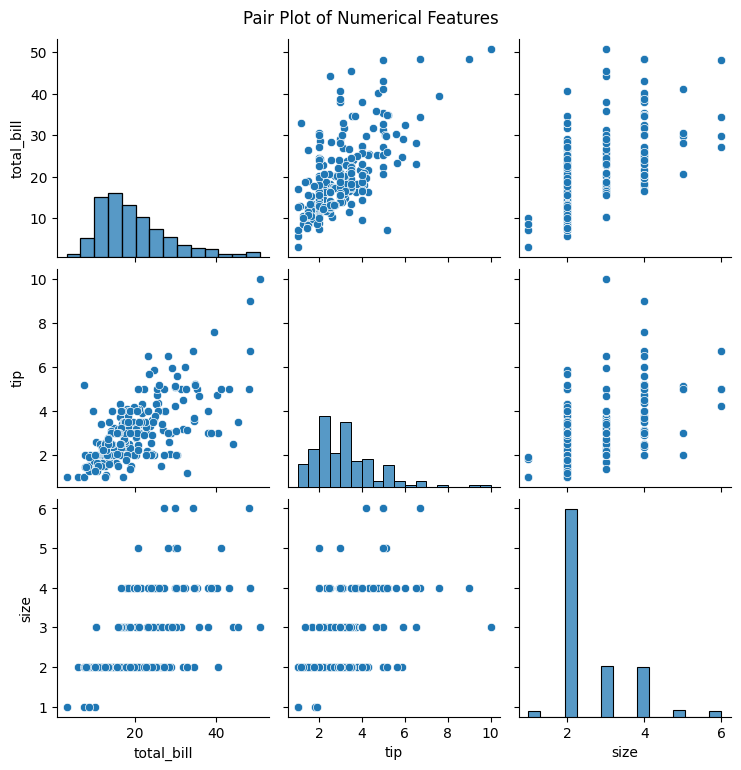

In [ ]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Generate a pair plot for numerical columns
pair_plot = sns.pairplot(df[numerical_cols])

# Add a title to the pair plot
pair_plot.fig.suptitle('Pair Plot of Numerical Features', y=1.02)

# Display the plot
plt.show()

## Identify correlations and outliers

### Subtask:
Analyze the heatmap and pair plot to identify strong correlations between features and potential outliers.


## Story with data

### Subtask:
Based on the visualizations and identified correlations/outliers,  derive insights from the data.


**Reasoning**:
Based on the previous analysis of the correlation matrix and pair plot,  key insights derived from these visualizations regarding tipping behavior, focusing on the relationships between `total_bill`, `tip`, and `size`, and highlighting any interesting patterns or potential outliers.



Insights from the Tips Dataset Visualizations:

Examining the correlation heatmap and pair plot for the numerical features (`total_bill`, `tip`, and `size`) reveals several key insights into tipping behavior at this restaurant.

1.  **Strong Positive Correlation between Total Bill and Tip:** The heatmap shows a strong positive correlation coefficient of 0.68 between `total_bill` and `tip`. This is visually confirmed in the scatter plot within the pair plot, where the points generally follow an upward trend: as the total bill increases, the tip amount also tends to increase. This is an expected and intuitive relationship, suggesting that customers typically tip a proportion of their bill.

2.  **Influence of Party Size on Bill and Tip:** There is a positive correlation between `size` and `total_bill` (0.60), and also between `size` and `tip` (0.49). This indicates that larger dining parties tend to have higher total bills, which subsequently leads to higher tip amounts. The scatter plots involving `size` show that points are clustered at discrete integer values for size, with the spread of `total_bill` and `tip` increasing as the party size increases.

3.  **Potential Outliers and Interesting Patterns:** While the general trends are clear, the scatter plots also reveal some interesting patterns and potential outliers:
    *   Most points align with the positive correlations, but there are instances of relatively high tips for moderate or even lower total bills, and vice versa. These could represent generous tippers, particularly good service experiences, or perhaps errors in data recording.
    *   The distribution of `tip` for smaller party sizes (`size` 1 or 2) appears more varied relative to the total bill compared to larger parties, although the sample size for larger parties is smaller.
    *   There might be a few individual data points that appear far from the main clusters in the scatter plots, potentially indicating outlier tipping behavior or unusual billing amounts(e.g., exceptionally good/bad service, special occasions).

In summary, the visualizations clearly demonstrate that the total bill is the primary driver of the tip amount, with the size of the dining party also playing a significant role by influencing the total bill. While the overall tipping behavior aligns with these factors, there is also variability and the presence of potential outliers that could warrant further exploration to understand tipping in this dataset.


## Summary:

### Data Analysis Key Findings

*   There is a strong positive correlation (0.68) between the total bill amount and the tip amount, indicating that higher bills tend to receive higher tips.
*   The size of the dining party is positively correlated with both the total bill (0.60) and the tip amount (0.49), suggesting that larger groups incur higher costs and consequently leave larger tips.
*   The pair plot reveals potential outliers where tips are relatively high for moderate or lower total bills, or vice versa, suggesting variability in tipping behavior beyond just the bill amount and party size.

###  Next Steps

*   Investigate the potential outliers to understand the circumstances behind unusual tipping amounts (e.g., exceptionally good/bad service, special occasions, data entry errors).
*   Further explore how categorical features like `sex`, `smoker`, `day`, and `time` influence the relationships between the numerical features and tipping behavior.


## Investigate Outliers and Categorical Feature Influence

### Subtask:
Visualizations to further investigate potential outliers and the influence of categorical features on the relationship between numerical features and tipping behavior.

**Reasoning**:
To further investigate outliers and how categorical features (`sex`, `smoker`, `day`, `time`) influence tipping behavior, We will create the following visualizations:

1.  **Scatter plot of `total_bill` vs `tip` with hue based on categorical features**: This will allow us to see if different categories exhibit different patterns in the relationship between the total bill and tip.
2.  **Box plots of `tip` by categorical features**: Box plots are useful for visualizing the distribution of a numerical variable across different categories and can help identify potential outliers within each category.

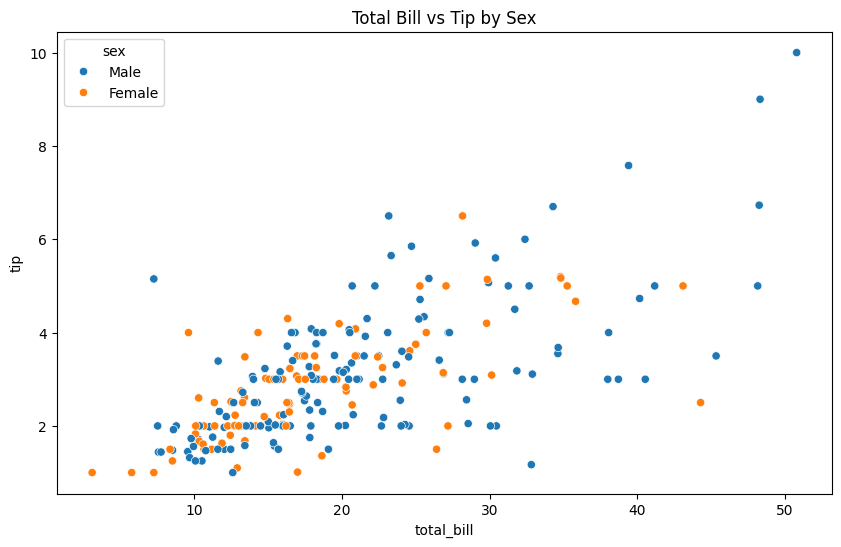

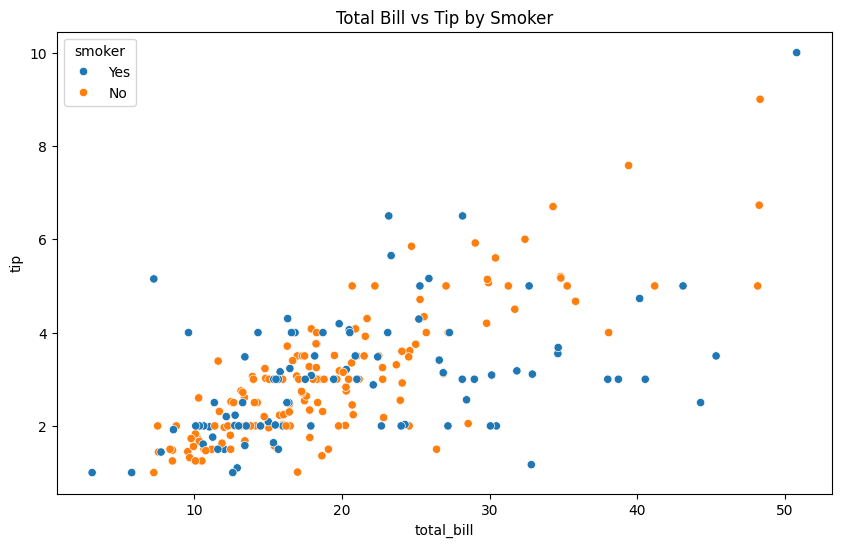

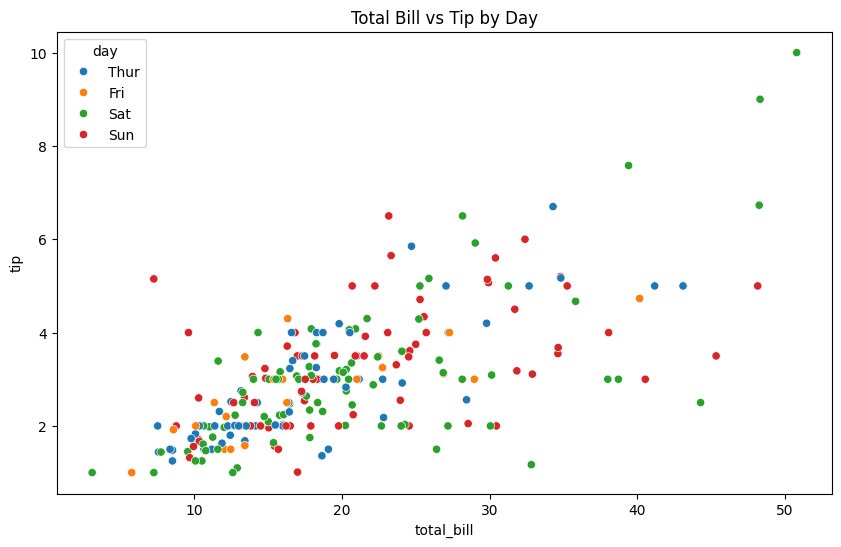

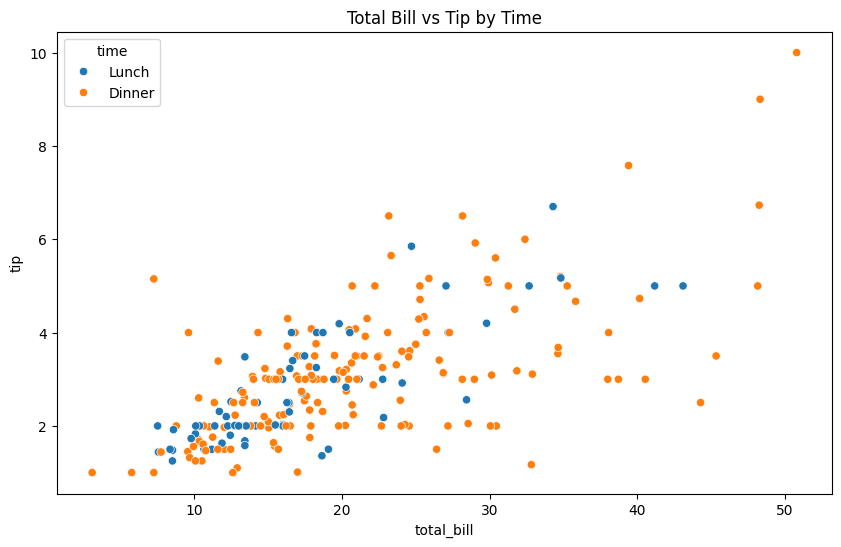

In [ ]:
# Scatter plot of total_bill vs tip with hue by sex
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title('Total Bill vs Tip by Sex')
plt.show()

# Scatter plot of total_bill vs tip with hue by smoker
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='smoker')
plt.title('Total Bill vs Tip by Smoker')
plt.show()

# Scatter plot of total_bill vs tip with hue by day
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='day')
plt.title('Total Bill vs Tip by Day')
plt.show()

# Scatter plot of total_bill vs tip with hue by time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time')
plt.title('Total Bill vs Tip by Time')
plt.show()

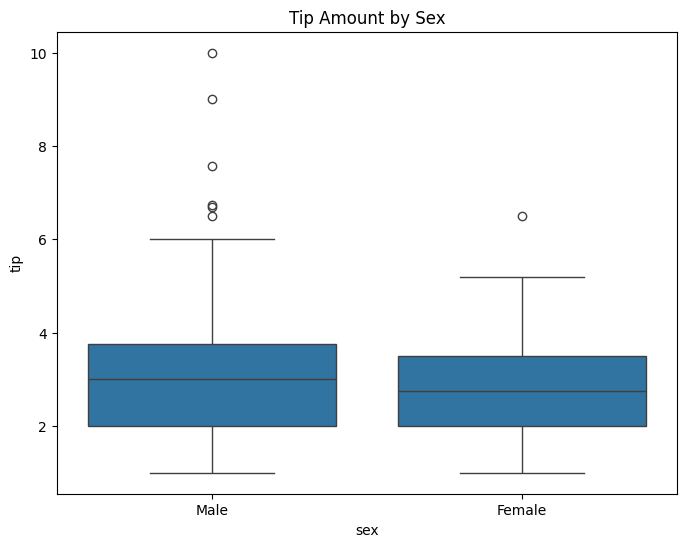

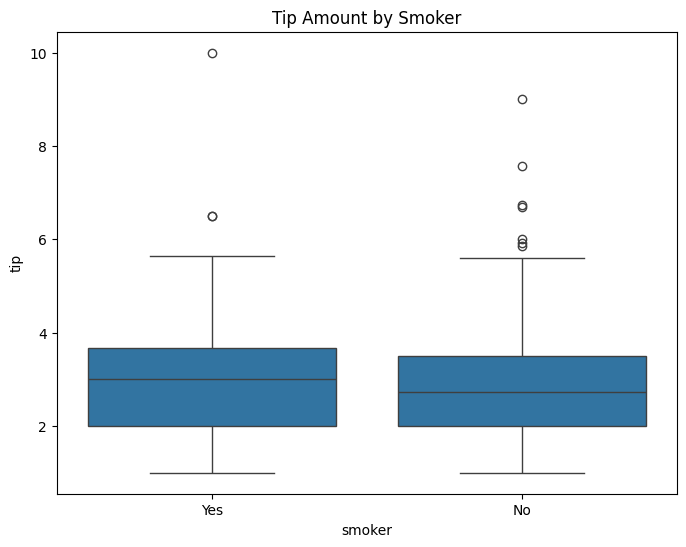

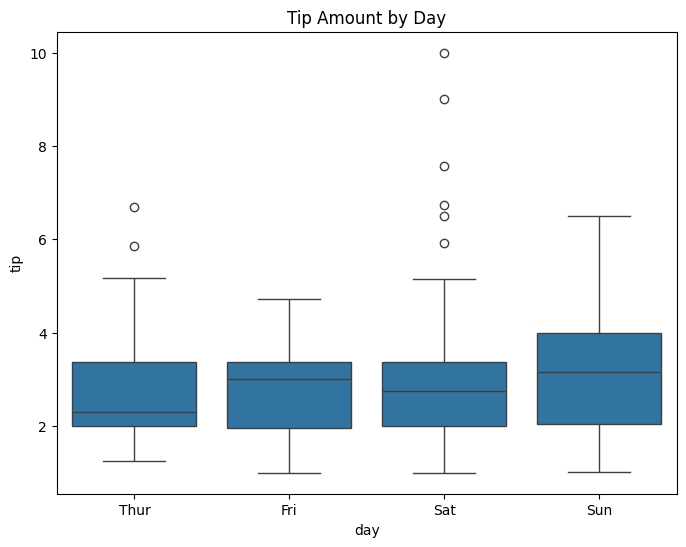

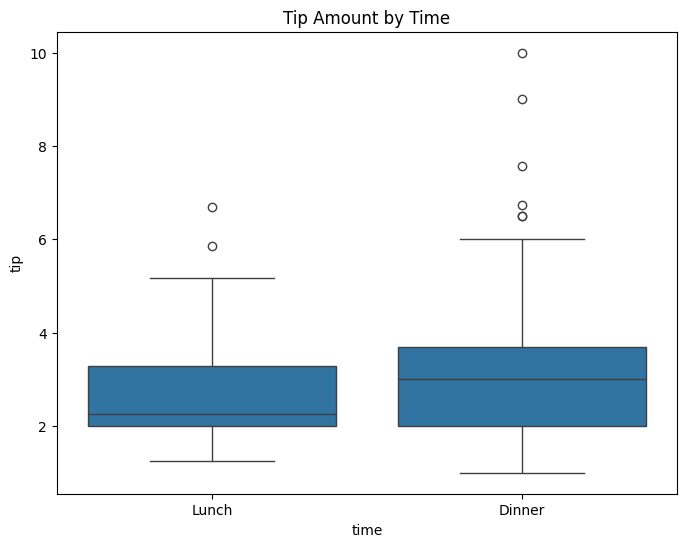

In [ ]:
# Box plot of tip by sex
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='sex', y='tip')
plt.title('Tip Amount by Sex')
plt.show()

# Box plot of tip by smoker
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='smoker', y='tip')
plt.title('Tip Amount by Smoker')
plt.show()

# Box plot of tip by day
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='day', y='tip')
plt.title('Tip Amount by Day')
plt.show()

# Box plot of tip by time
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='time', y='tip')
plt.title('Tip Amount by Time')
plt.show()